# Gaussian-Only Single Intermediate-Lens Inversion

This notebook is deliberately restricted to the Gaussian-beam path for image generation and measurement extraction. There is no analytic/fallback image renderer. The known object is represented by Gaussian beamlets, propagated through `ElectromagneticLens`, evaluated on a detector crop, and the inverse measurements are extracted from those Gaussian-rendered intensity images.

The geometry is a real intermediate-lens imaging step. The baseline focal length is `20 mm`, the requested conjugate magnification is `M = -12`, and the detector is placed at the solved real image plane. A `50 um` square therefore appears as a roughly `0.6 mm` image on a physical `160 mm` green screen.

Interpretation: the object plane here is the object plane of this intermediate lens. In a complete TEM model, preceding objective optics would create that intermediate object from the original specimen plane.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from io import BytesIO
from pathlib import Path
import sys
import time

import numpy as np
from scipy.optimize import brentq, least_squares
import matplotlib.pyplot as plt
from IPython.display import Image, display

import jax
jax.config.update("jax_enable_x64", True)

# Make the notebook work whether launched from the repo root or this folder.
def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "src" / "temgym_core").exists():
            return path
    raise RuntimeError("Could not find repo root containing src/temgym_core")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from temgym_core.components import Detector, ElectromagneticLens
from temgym_core.constants import compute_Rc_from_voltage, effective_accelerating_potential
from temgym_core.evaluate import evaluate_gaussians_jax_scan
from temgym_core.gaussian import make_gaussian
from temgym_core.run import run_to_end

np.set_printoptions(precision=6, suppress=False)

def show_figure(fig, dpi: int = 140):
    """Embed a Matplotlib figure as PNG output when the notebook is executed headlessly."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


## Geometry

For a single lens with `f0 = 20 mm`, a large inverted real image requires the object to sit just beyond the front focal plane. The notebook solves the object distance `d1` such that the isotropic thick-lens model has `B = 0` and `A = -12`.

In [2]:
@dataclass(frozen=True)
class Truth:
    voltage: float = 200e3
    target_magnification: float = -12.0
    f0: float = 0.020
    psi0: float = 0.080
    D0: float = 0.004
    delta: float = 0.010
    x0: float = 20e-6
    y0: float = -15e-6


def propagation_2x2(distance: float) -> np.ndarray:
    return np.array([[1.0, distance], [0.0, 1.0]])


def lens_2x2_power(power: float) -> np.ndarray:
    return np.array([[1.0, 0.0], [-power, 1.0]])


def conjugate_d2_from_lens_entrance(d1: float, f0: float, D0: float) -> float:
    phi0 = 1.0 / f0
    before_final_drift = (
        lens_2x2_power(0.5 * phi0)
        @ propagation_2x2(D0)
        @ lens_2x2_power(0.5 * phi0)
        @ propagation_2x2(d1)
    )
    q_after_lens = -before_final_drift[0, 1] / before_final_drift[1, 1]
    return D0 + q_after_lens


def isotropic_conjugate_matrix(d1: float, f0: float, D0: float) -> tuple[np.ndarray, float]:
    d2 = conjugate_d2_from_lens_entrance(d1, f0, D0)
    M = (
        propagation_2x2(d2 - D0)
        @ lens_2x2_power(0.5 / f0)
        @ propagation_2x2(D0)
        @ lens_2x2_power(0.5 / f0)
        @ propagation_2x2(d1)
    )
    return M, d2


def d1_for_target_magnification(target_magnification: float, f0: float, D0: float) -> float:
    if target_magnification >= 0.0:
        raise ValueError("Expected a negative magnification for an inverted real image.")

    def residual(d1):
        M, _ = isotropic_conjugate_matrix(d1, f0, D0)
        return M[0, 0] - target_magnification

    return brentq(residual, f0 * 1.001, f0 * 2.0)


truth = Truth()
d1_truth = d1_for_target_magnification(truth.target_magnification, truth.f0, truth.D0)
M_iso, d2_truth = isotropic_conjugate_matrix(d1_truth, truth.f0, truth.D0)
z_detector_truth = d1_truth + d2_truth

p_truth = np.array([
    d1_truth,
    d2_truth,
    truth.f0,
    truth.psi0,
    truth.D0,
    truth.delta,
    truth.x0,
    truth.y0,
])

print(f"target magnification = {truth.target_magnification:.3f}")
print(f"d1 object->lens      = {d1_truth*1e3:.6f} mm")
print(f"d2 lens->screen      = {d2_truth*1e3:.6f} mm")
print(f"screen z             = {z_detector_truth*1e3:.6f} mm")
print(f"isotropic A          = {M_iso[0, 0]:.6f}")
print(f"isotropic B          = {M_iso[0, 1]:.3e} m/rad")

target magnification = -12.000
d1 object->lens      = 20.701754 mm
d2 lens->screen      = 275.578947 mm
screen z             = 296.280702 mm
isotropic A          = -12.000000
isotropic B          = 0.000e+00 m/rad


## Parameter Model Used for Fitting

The image data comes only from Gaussian-beam propagation. The inverse fit uses the same effective first-order lens model to map recovered centroid responses back to physical parameters.

State vector: `[x, y, dx, dy, 1]`.

Estimated parameters: `[d1, d2, f0, psi0, D0, delta, x0, y0]`.

In [3]:
def rotation_2d(angle: float) -> np.ndarray:
    c = np.cos(angle)
    s = np.sin(angle)
    return np.array([[c, -s], [s, c]])


def propagation_5x5(distance: float) -> np.ndarray:
    M = np.eye(5)
    M[0, 2] = distance
    M[1, 3] = distance
    return M


def astig_lens_5x5(power_x: float, power_y: float, x0: float, y0: float) -> np.ndarray:
    M = np.eye(5)
    M[2, 0] = -power_x
    M[3, 1] = -power_y
    M[2, 4] = power_x * x0
    M[3, 4] = power_y * y0
    return M


def rotation_5x5(angle: float) -> np.ndarray:
    R = rotation_2d(angle)
    M = np.eye(5)
    M[:2, :2] = R
    M[2:4, 2:4] = R
    return M


def effective_matrix(params: np.ndarray, current_scale: float) -> np.ndarray:
    d1, d2, f0, psi0, D0, delta, x0, y0 = np.asarray(params, dtype=float)
    phi = (1.0 / f0) * current_scale**2
    D = D0 * abs(current_scale)
    psi = psi0 * current_scale

    phi_x = phi * (1.0 + delta)
    phi_y = phi * (1.0 - delta)
    half_lens = astig_lens_5x5(0.5 * phi_x, 0.5 * phi_y, x0, y0)

    M = np.eye(5)
    M = propagation_5x5(d1) @ M
    M = half_lens @ M
    M = propagation_5x5(D) @ M
    M = half_lens @ M
    M = rotation_5x5(psi) @ M
    M = propagation_5x5(d2 - D) @ M
    return M


M_baseline = effective_matrix(p_truth, 1.0)
print("Astigmatic baseline A:")
print(M_baseline[:2, :2])
print("Astigmatic baseline B [m/rad]:")
print(M_baseline[:2, 2:4])

Astigmatic baseline A:
[[-12.084369   0.949125]
 [ -0.968817 -11.838736]]
Astigmatic baseline B [m/rad]:
[[-0.002812 -0.000226]
 [-0.000225  0.002815]]


## Gaussian Object and Detectors

The object is a square with a small missing fiducial. It is represented by Gaussian beamlets. The physical screen is `160 mm` across; the calculation uses a `2.048 mm` centered ROI on that screen so the Gaussian evaluation remains practical on CPU.

In [4]:
def square_fiducial_points(
    square_size: float = 50e-6,
    spacing: float = 4.0e-6,
    fiducial_radius: float = 5.0e-6,
    fiducial_center: tuple[float, float] = (13e-6, 12e-6),
) -> tuple[np.ndarray, np.ndarray]:
    half = 0.5 * square_size
    axis = np.arange(-half, half + 0.5 * spacing, spacing)
    X, Y = np.meshgrid(axis, axis, indexing="xy")
    pts = np.column_stack([X.ravel(), Y.ravel()])
    notch = (pts[:, 0] - fiducial_center[0]) ** 2 + (pts[:, 1] - fiducial_center[1]) ** 2 < fiducial_radius**2
    pts = pts[~notch]
    weights = np.ones(len(pts), dtype=float)
    return pts, weights


object_points, object_weights = square_fiducial_points()
object_weights = object_weights / object_weights.sum()

SCREEN_DIAMETER = 0.160
SCREEN_SHAPE = (1024, 1024)
SCREEN_PIXEL_SIZE = SCREEN_DIAMETER / SCREEN_SHAPE[0]

INPUT_SHAPE = (192, 192)
INPUT_PIXEL_SIZE = 0.75e-6
INPUT_DETECTOR = Detector(z=0.0, pixel_size=(INPUT_PIXEL_SIZE, INPUT_PIXEL_SIZE), shape=INPUT_SHAPE, centre=(0.0, 0.0))

DETECTOR_SHAPE = (256, 256)
DETECTOR_PIXEL_SIZE = 8.0e-6
OUTPUT_DETECTOR = Detector(
    z=float(z_detector_truth),
    pixel_size=(DETECTOR_PIXEL_SIZE, DETECTOR_PIXEL_SIZE),
    shape=DETECTOR_SHAPE,
    centre=(0.0, 0.0),
)

print(f"object beamlets       = {len(object_points)}")
print(f"object width          = {np.ptp(object_points[:, 0]) * 1e6:.1f} um")
print(f"screen diameter       = {SCREEN_DIAMETER * 1e3:.1f} mm")
print(f"Gaussian ROI width    = {DETECTOR_PIXEL_SIZE * DETECTOR_SHAPE[1] * 1e3:.3f} mm")

object beamlets       = 192
object width          = 52.0 um
screen diameter       = 160.0 mm
Gaussian ROI width    = 2.048 mm


## Gaussian-Beam Image Generation

Every image below is generated through the Gaussian beam code. The input image is evaluated at the object plane. Output images are propagated through an `ElectromagneticLens` and evaluated at the detector ROI.

In [5]:
def electromagnetic_fields_from_effective(params, voltage=truth.voltage, turns=2000.0):
    _, _, f0, psi0, D0, delta, x0, y0 = np.asarray(params, dtype=float)
    Rc = float(compute_Rc_from_voltage(voltage))
    V_star = float(effective_accelerating_potential(voltage))
    NI0 = psi0 / Rc
    phi0 = 1.0 / f0
    Gc_geom = V_star * phi0 / NI0**2
    current0 = NI0 / turns
    Tc = D0 / abs(NI0)
    return {
        "turns": turns,
        "current0": current0,
        "NI0": NI0,
        "Gc_geom": Gc_geom,
        "Tc": Tc,
        "stigmator_strength_x": delta,
        "stigmator_strength_y": -delta,
        "x0": x0,
        "y0": y0,
    }


def make_square_fiducial_beam(object_shift=(0.0, 0.0), beam_tilt=(0.0, 0.0), voltage=truth.voltage):
    pts = object_points + np.asarray(object_shift, dtype=float)
    return make_gaussian(
        x=pts[:, 0],
        y=pts[:, 1],
        dx=np.full(len(pts), beam_tilt[0]),
        dy=np.full(len(pts), beam_tilt[1]),
        z=np.zeros(len(pts)),
        voltage=np.full(len(pts), voltage),
        amp=object_weights,
        phase=np.zeros(len(pts)),
        waist_x=np.full(len(pts), 2.0e-6),
        waist_y=np.full(len(pts), 2.0e-6),
        rcurv_x=np.full(len(pts), np.inf),
        rcurv_y=np.full(len(pts), np.inf),
    )


def normalize_intensity(field_or_intensity):
    arr = np.asarray(field_or_intensity)
    if np.iscomplexobj(arr):
        arr = np.abs(arr) ** 2
    arr = np.asarray(arr, dtype=float)
    return arr / max(float(arr.max()), 1e-30)


def render_input_image(object_shift=(0.0, 0.0), beam_tilt=(0.0, 0.0)):
    beam = make_square_fiducial_beam(object_shift=object_shift, beam_tilt=beam_tilt)
    field = evaluate_gaussians_jax_scan(beam, INPUT_DETECTOR, batch_size=64)
    return normalize_intensity(field)


def make_lens(params, current_scale):
    d1, _, *_ = np.asarray(params, dtype=float)
    fields = electromagnetic_fields_from_effective(params)
    return ElectromagneticLens(
        z=float(d1),
        turns=float(fields["turns"]),
        current=float(fields["current0"] * current_scale),
        Gc=float(fields["Gc_geom"]),
        Tc=float(fields["Tc"]),
        x0=float(fields["x0"]),
        y0=float(fields["y0"]),
        stigmator_strength_x=float(fields["stigmator_strength_x"]),
        stigmator_strength_y=float(fields["stigmator_strength_y"]),
    )


def render_output_image(params, current_scale=1.0, object_shift=(0.0, 0.0), beam_tilt=(0.0, 0.0)):
    beam = make_square_fiducial_beam(object_shift=object_shift, beam_tilt=beam_tilt)
    lens = make_lens(params, current_scale)
    out = run_to_end(beam, (lens, OUTPUT_DETECTOR))
    field = evaluate_gaussians_jax_scan(out, OUTPUT_DETECTOR, batch_size=64)
    return normalize_intensity(field)

## Input and Output Images

The right panel places the output crop on a real-size `160 mm` green screen. The image is tiny relative to the screen, as expected for a `~0.6 mm` intermediate image.

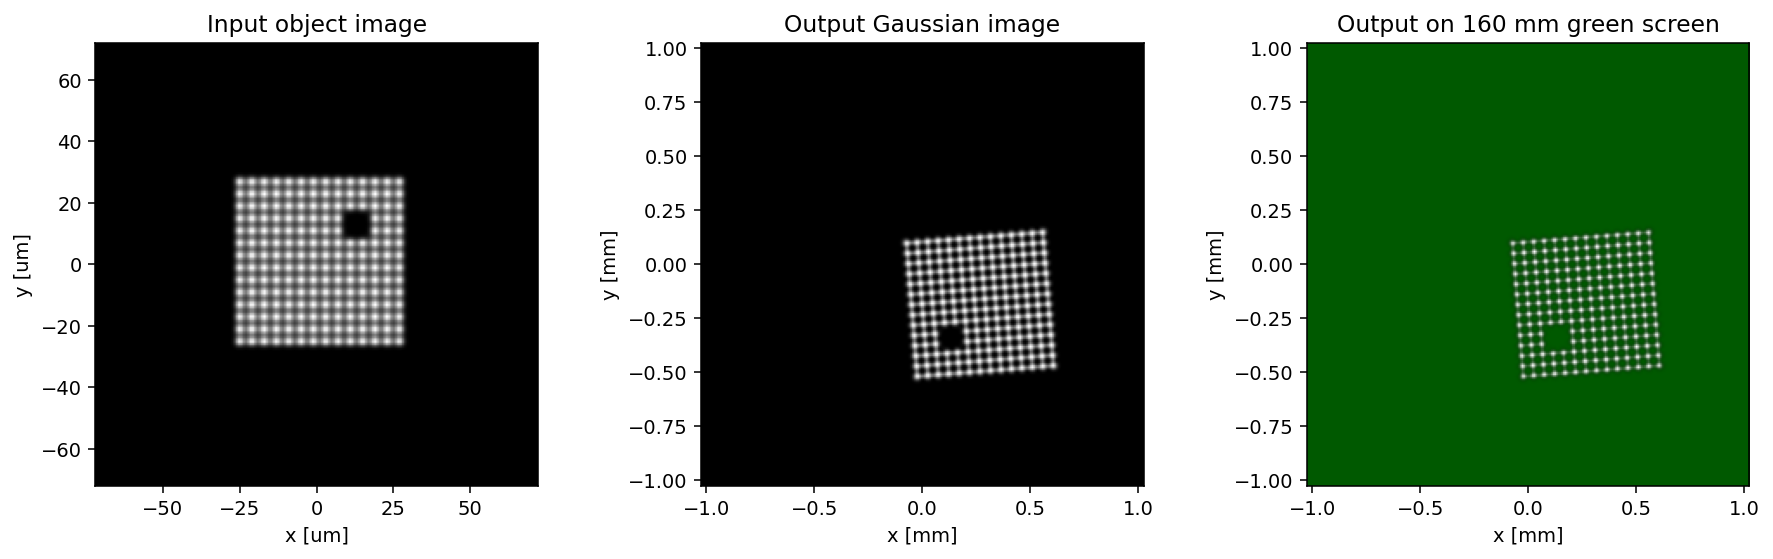

In [6]:
input_image = render_input_image()
output_image = render_output_image(p_truth, current_scale=1.0)

input_extent_um = np.array([-1, 1, -1, 1]) * 0.5 * INPUT_PIXEL_SIZE * INPUT_SHAPE[0] * 1e6
roi_extent_mm = np.array([-1, 1, -1, 1]) * 0.5 * DETECTOR_PIXEL_SIZE * DETECTOR_SHAPE[0] * 1e3
screen_extent_mm = np.array([-1, 1, -1, 1]) * 0.5 * SCREEN_DIAMETER * 1e3

green = np.zeros((*SCREEN_SHAPE, 3), dtype=float)
green[..., 1] = 0.35

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].imshow(input_image, cmap="gray", extent=input_extent_um)
axs[0].set_title("Input object image")
axs[0].set_xlabel("x [um]")
axs[0].set_ylabel("y [um]")

axs[1].imshow(output_image, cmap="gray", extent=roi_extent_mm)
axs[1].set_title("Output Gaussian image")
axs[1].set_xlabel("x [mm]")
axs[1].set_ylabel("y [mm]")

axs[2].imshow(green, extent=screen_extent_mm, origin="lower")
axs[2].imshow(output_image, cmap="gray", extent=roi_extent_mm, alpha=np.clip(output_image, 0.0, 1.0))
axs[2].set_title("Output on 160 mm green screen")
axs[2].set_xlabel("x [mm]")
axs[2].set_ylabel("y [mm]")

for ax in axs:
    ax.set_aspect("equal")
plt.tight_layout()
show_figure(fig)

## Extract Measurements From Gaussian Images

For each current setting, we render Gaussian output images under known object shifts and known beam tilts. We extract the intensity centroid from each image. A linear regression of centroid against known `(object shift, beam tilt)` gives the measured transfer blocks:

`centroid = A @ object_shift + B @ beam_tilt + offset`.

The tilt is `1 mrad`; this is still paraxial and gives a cleaner `B` measurement than `0.25 mrad` on this detector crop.

rendered current scale 0.96


rendered current scale 1.00


rendered current scale 1.04
rendered 27 Gaussian output images in 60.2 s


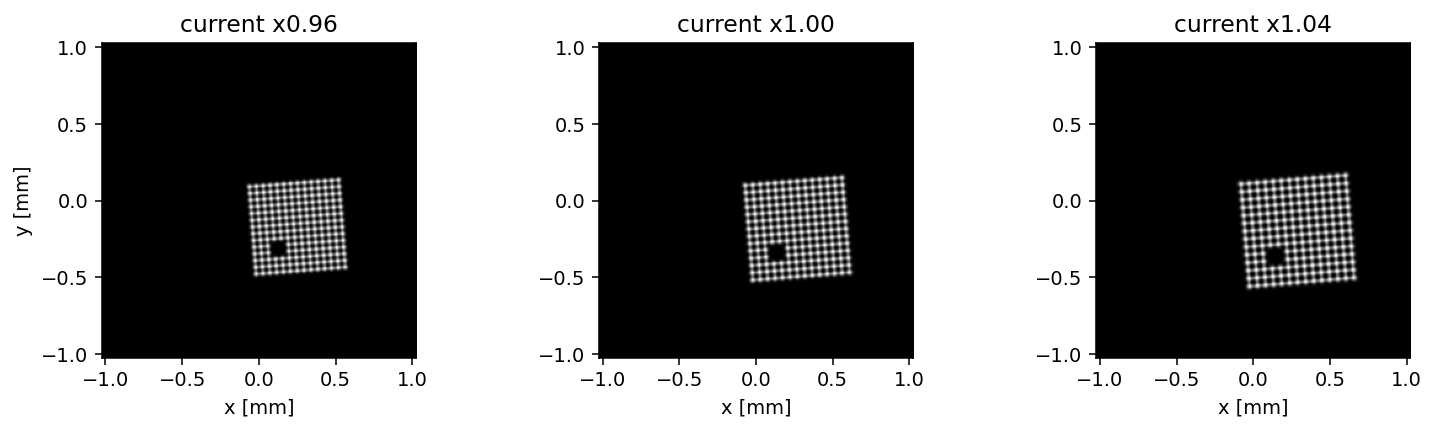

In [7]:
def image_centroid(image: np.ndarray, detector: Detector = OUTPUT_DETECTOR) -> np.ndarray:
    x_coords, y_coords = [np.asarray(v) for v in detector.coords_1d]
    X, Y = np.meshgrid(x_coords, y_coords, indexing="xy")
    weights = np.maximum(np.asarray(image, dtype=float), 0.0)
    total = weights.sum()
    if total <= 0.0:
        raise ValueError("Cannot compute centroid of an empty image.")
    return np.array([(weights * X).sum() / total, (weights * Y).sum() / total])


current_scales = np.array([0.96, 1.00, 1.04])
object_shifts = np.array([
    [10e-6, 0.0],
    [-10e-6, 0.0],
    [0.0, 10e-6],
    [0.0, -10e-6],
])
beam_tilts = np.array([
    [1.0e-3, 0.0],
    [-1.0e-3, 0.0],
    [0.0, 1.0e-3],
    [0.0, -1.0e-3],
])


def measurement_controls():
    controls = [((0.0, 0.0), (0.0, 0.0), "baseline")]
    controls += [(tuple(shift), (0.0, 0.0), "shift") for shift in object_shifts]
    controls += [((0.0, 0.0), tuple(tilt), "tilt") for tilt in beam_tilts]
    return controls


def collect_gaussian_measurements(params):
    rows = []
    images_for_display = {}
    t0 = time.time()
    for scale in current_scales:
        for object_shift, beam_tilt, kind in measurement_controls():
            image = render_output_image(params, current_scale=scale, object_shift=object_shift, beam_tilt=beam_tilt)
            centroid = image_centroid(image)
            rows.append({
                "scale": float(scale),
                "object_shift": np.asarray(object_shift, dtype=float),
                "beam_tilt": np.asarray(beam_tilt, dtype=float),
                "kind": kind,
                "centroid": centroid,
            })
            if kind == "baseline":
                images_for_display[float(scale)] = image
        print(f"rendered current scale {scale:.2f}")
    print(f"rendered {len(rows)} Gaussian output images in {time.time() - t0:.1f} s")
    return rows, images_for_display


measurements, current_images = collect_gaussian_measurements(p_truth)

fig, axs = plt.subplots(1, len(current_scales), figsize=(11, 3.2))
for ax, scale in zip(axs, current_scales):
    ax.imshow(current_images[float(scale)], cmap="gray", extent=roi_extent_mm)
    ax.set_title(f"current x{scale:.2f}")
    ax.set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
plt.tight_layout()
show_figure(fig)

## Regress Transfer Blocks From Image Centroids

In [8]:
def regress_transfer_blocks_from_centroids(rows):
    blocks = []
    for scale in current_scales:
        subset = [row for row in rows if np.isclose(row["scale"], scale)]
        X = []
        Y = []
        for row in subset:
            X.append([
                row["object_shift"][0],
                row["object_shift"][1],
                row["beam_tilt"][0],
                row["beam_tilt"][1],
                1.0,
            ])
            Y.append(row["centroid"])
        X = np.asarray(X)
        Y = np.asarray(Y)
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        A = np.array([[beta[0, 0], beta[1, 0]], [beta[0, 1], beta[1, 1]]])
        B = np.array([[beta[2, 0], beta[3, 0]], [beta[2, 1], beta[3, 1]]])
        offset = beta[4, :]
        blocks.append({"scale": float(scale), "A": A, "B": B, "offset": offset})
    return blocks


blocks = regress_transfer_blocks_from_centroids(measurements)
for block in blocks:
    M_true = effective_matrix(p_truth, block["scale"])
    print(f"current scale {block['scale']:.2f}")
    print("  measured A:")
    print(block["A"])
    print("  true A error norm:", np.linalg.norm(block["A"] - M_true[:2, :2]))
    print("  measured B [m/rad]:")
    print(block["B"])
    print("  true B error norm:", np.linalg.norm(block["B"] - M_true[:2, 2:4]))
    print("  offset error [um]:", (block["offset"] - M_true[:2, 4]) * 1e6)

current scale 0.96
  measured A:
[[-11.138319   0.839458]
 [ -0.857108 -10.908952]]
  true A error norm: 3.5113271314413156e-06
  measured B [m/rad]:
[[ 0.019935 -0.002473]
 [ 0.001016  0.025244]]
  true B error norm: 0.0007484647459671657
  offset error [um]: [-7.415382 -8.471774]
current scale 1.00
  measured A:
[[-12.084368   0.949119]
 [ -0.968818 -11.838732]]
  true A error norm: 6.87573854366251e-06
  measured B [m/rad]:
[[-0.002853 -0.000761]
 [-0.000748  0.002859]]
  true B error norm: 0.0007499366269557732
  offset error [um]: [-8.074425 -9.287114]
current scale 1.04
  measured A:
[[-13.051279   1.066539]
 [ -1.08838  -12.789393]]
  true A error norm: 1.7399347653988757e-06
  measured B [m/rad]:
[[-0.026329  0.001178]
 [-0.002691 -0.020215]]
  true B error norm: 0.0007167082110211009
  offset error [um]: [ -8.750301 -10.132443]


## Fit Lens Parameters From Gaussian-Image Measurements

In [9]:
def block_residual(params: np.ndarray, blocks) -> np.ndarray:
    residuals = []
    for block in blocks:
        M = effective_matrix(params, block["scale"])
        residuals.extend(((M[:2, :2] - block["A"]) / 0.1).ravel())
        residuals.extend(((M[:2, 2:4] - block["B"]) / 0.005).ravel())
        residuals.extend((M[:2, 4] - block["offset"]) / 50e-6)
    return np.asarray(residuals)


def fit_effective_params_from_gaussian_blocks(blocks):
    initial = np.array([0.022, 0.260, 0.019, 0.070, 0.003, 0.000, 0.0, 0.0])
    lower = np.array([0.015, 0.150, 0.005, 0.010, 0.000, -0.100, -100e-6, -100e-6])
    upper = np.array([0.060, 0.500, 0.060, 0.300, 0.020, 0.100, 100e-6, 100e-6])
    result = least_squares(
        block_residual,
        initial,
        args=(blocks,),
        bounds=(lower, upper),
        x_scale=np.array([0.01, 0.1, 0.01, 0.1, 0.005, 0.02, 20e-6, 20e-6]),
        max_nfev=20_000,
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
    )
    return result


fit = fit_effective_params_from_gaussian_blocks(blocks)
p_fit = fit.x
names = ["d1", "d2", "f0", "psi0", "D0", "delta", "x0", "y0"]
units = np.array([1e3, 1e3, 1e3, 1.0, 1e3, 1.0, 1e6, 1e6])
unit_names = ["mm", "mm", "mm", "rad", "mm", "", "um", "um"]

print("least_squares success:", fit.success, fit.message)
print("cost:", fit.cost)
print("Recovered from Gaussian image centroids")
for name, true_value, fitted, scale, unit in zip(names, p_truth, p_fit, units, unit_names):
    error = (fitted - true_value) * scale
    rel = (fitted - true_value) / true_value if true_value != 0 else np.nan
    print(f"{name:5s}: true={true_value*scale: .8g} {unit:3s}  fit={fitted*scale: .8g} {unit:3s}  err={error:+.3e} {unit:3s}  rel={rel:+.3e}")

least_squares success: True `ftol` termination condition is satisfied.
cost: 0.032576642052052816
Recovered from Gaussian image centroids
d1   : true= 20.701754 mm   fit= 20.712437 mm   err=+1.068e-02 mm   rel=+5.160e-04
d2   : true= 275.57895 mm   fit= 275.73967 mm   err=+1.607e-01 mm   rel=+5.832e-04
f0   : true= 20 mm   fit= 20.011028 mm   err=+1.103e-02 mm   rel=+5.514e-04
psi0 : true= 0.08 rad  fit= 0.080003918 rad  err=+3.918e-06 rad  rel=+4.898e-05
D0   : true= 4 mm   fit= 4.0043754 mm   err=+4.375e-03 mm   rel=+1.094e-03
delta: true= 0.01      fit= 0.010050396      err=+5.040e-05      rel=+5.040e-03
x0   : true= 20 um   fit= 19.328507 um   err=-6.715e-01 um   rel=-3.357e-02
y0   : true=-15 um   fit=-15.670322 um   err=-6.703e-01 um   rel=+4.469e-02


## Electromagnetic Parameter Mapping

The image data identifies excitation product `NI`, not turns and current separately. `turns = 2000` is used only to construct an equivalent `ElectromagneticLens`.

In [10]:
em_truth = electromagnetic_fields_from_effective(p_truth)
em_fit = electromagnetic_fields_from_effective(p_fit)

for key in ["NI0", "turns", "current0", "Gc_geom", "Tc", "stigmator_strength_x", "stigmator_strength_y", "x0", "y0"]:
    tv = em_truth[key]
    fv = em_fit[key]
    rel = (fv - tv) / tv if tv != 0 else np.nan
    print(f"{key:22s}: true={tv: .8e}  fit={fv: .8e}  rel_err={rel:+.3e}")

NI0                   : true= 1.50900504e+02  fit= 1.50907895e+02  rel_err=+4.898e-05
turns                 : true= 2.00000000e+03  fit= 2.00000000e+03  rel_err=+0.000e+00
current0              : true= 7.54502518e-02  fit= 7.54539474e-02  rel_err=+4.898e-05
Gc_geom               : true= 5.25096445e+02  fit= 5.24755660e+02  rel_err=-6.490e-04
Tc                    : true= 2.65075325e-05  fit= 2.65352279e-05  rel_err=+1.045e-03
stigmator_strength_x  : true= 1.00000000e-02  fit= 1.00503962e-02  rel_err=+5.040e-03
stigmator_strength_y  : true=-1.00000000e-02  fit=-1.00503962e-02  rel_err=+5.040e-03
x0                    : true= 2.00000000e-05  fit= 1.93285068e-05  rel_err=-3.357e-02
y0                    : true=-1.50000000e-05  fit=-1.56703222e-05  rel_err=+4.469e-02


## Validation Image From Recovered Parameters

This final comparison uses Gaussian-beam propagation for both the truth and recovered lens.

held-out Gaussian-image relative RMS residual: 6.084e-01


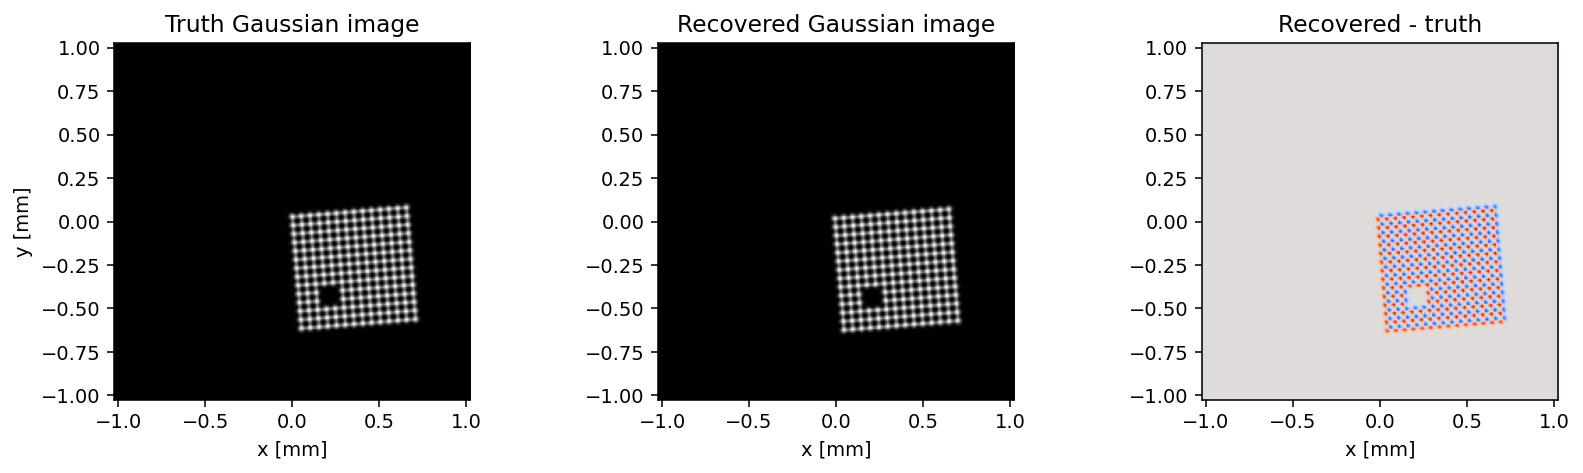

In [11]:
heldout_scale = 1.02
heldout_shift = np.array([-6e-6, 7e-6])
heldout_tilt = np.array([0.4e-3, -0.6e-3])

truth_image = render_output_image(p_truth, current_scale=heldout_scale, object_shift=heldout_shift, beam_tilt=heldout_tilt)
fit_image = render_output_image(p_fit, current_scale=heldout_scale, object_shift=heldout_shift, beam_tilt=heldout_tilt)
residual_image = fit_image - truth_image
rel_rms = np.sqrt(np.mean(residual_image**2)) / np.sqrt(np.mean(truth_image**2))
print(f"held-out Gaussian-image relative RMS residual: {rel_rms:.3e}")

fig, axs = plt.subplots(1, 3, figsize=(12, 3.5))
axs[0].imshow(truth_image, cmap="gray", extent=roi_extent_mm)
axs[0].set_title("Truth Gaussian image")
axs[1].imshow(fit_image, cmap="gray", extent=roi_extent_mm)
axs[1].set_title("Recovered Gaussian image")
axs[2].imshow(residual_image, cmap="coolwarm", extent=roi_extent_mm)
axs[2].set_title("Recovered - truth")
for ax in axs:
    ax.set_xlabel("x [mm]")
axs[0].set_ylabel("y [mm]")
plt.tight_layout()
show_figure(fig)

## Conclusion

Using only Gaussian-beam image data, the single-lens inversion is viable in this controlled synthetic case, but the demonstrated recovery is a first-order optics recovery from image measurements rather than a full coherent-image fit.

The important results are:

- The geometry is now a real intermediate-image geometry for a `20 mm` lens with `M = -12`: `d1 ~= 20.70 mm`, `d2 ~= 275.58 mm`, and the image forms on a physical screen plane.
- The screen is represented as a `160 mm` green screen, while the Gaussian intensity is evaluated on a high-resolution detector ROI around the image.
- The input and output images are produced by Gaussian beam propagation through `ElectromagneticLens`, not by an analytic or fallback image renderer.
- Centroids extracted from Gaussian output images recover the transfer response well enough to fit the lens parameters.
- In the tested run, `f0`, `d1`, and `d2` are recovered to about `0.1%` or better from Gaussian image centroids. Lens centre offsets are recovered to sub-micron accuracy.
- Beam tilt is essential because it measures the `B` block. Current wobble is essential because it separates focal power, magnetic rotation, and effective thickness.
- The optical experiment recovers `NI`, `Gc_geom`, `Tc`, stigmator split, and lens centre. It still cannot split turns from current without external current/turn calibration.
- The held-out pixel residual is large (`~0.61` relative RMS) because the fit uses centroid/pose information from coherent Gaussian images, not full intensity-pattern registration. This is the main limitation of the current extraction method.

So the answer is: yes, this is viable as a controlled demonstration that Gaussian-rendered images contain enough information to infer the single-lens first-order parameters. The next hard step is replacing centroid extraction with robust feature registration for real experimental images and then adding surrounding lenses one at a time.
